### Import all required libraries

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [ ]:
# Get the randomness, ensure consistant random distribution
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Load training and testing data

In [ ]:
# 1) Load data

# Load training dataset
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")

# Explore dataset
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())  # Display the attribute name
display(train_df.head())                      # View train_df

# Load training dataset
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

# Explore dataset
print("\nShape:", test_df.shape)
print("Columns:", test_df.columns.tolist())  # Display the attribute name
display(test_df.head())                      # View test_df

Shape: (440833, 12)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0



Shape: (64374, 12)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


### Check data imbalance

In [ ]:
train_df['Churn'].value_counts()
test_df['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


Explanation:  
As the data is imbalance, we need to do stratification. We first merge both datasets to ensure preprocessing is consistent and for further stratification step.

### Merge training and testing dataset

In [ ]:
# Merge train and test CSVs into one dataset
df_all = pd.concat([train_df, test_df], axis=0)
# So we can do preprocessing together

### Visualise the data

In [ ]:
# Show (describe) the statistics of the training and testing dataset
df_all.describe()


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
# Access the columns with the correct name, if it exists
df_all["Tenure"].value_counts

<bound method IndexOpsMixin.value_counts of 0        39.0
1        49.0
2        14.0
3        38.0
4        32.0
         ... 
64369    33.0
64370     6.0
64371    39.0
64372    18.0
64373    45.0
Name: Tenure, Length: 505207, dtype: float64>

In [ ]:
# Show the column names with their corresponding data types
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505207 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


### Check missing value

In [ ]:
# check if there any null values
df_all.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


### Choose target column

In [ ]:
TARGET_COL = None

if TARGET_COL is None:
    candidate_names = ["churn", "churn_type", "churntype", "label", "target", "class", "y"]
    lower_map = {c.lower(): c for c in df_all.columns}
    for key in candidate_names:
        for lc, orig in lower_map.items():
            if key == lc or key in lc:
                TARGET_COL = orig
                break
        if TARGET_COL is not None:
            break

if TARGET_COL is None:
    TARGET_COL = df_all.columns[-1]

print("Using TARGET_COL =", TARGET_COL)

# Drop the rows with missing target values from df_all before separating features and target
df_all = df_all.dropna(subset=[TARGET_COL])

# Separate features and target
X = df_all.drop(columns=[TARGET_COL, "CustomerID"])
y = df_all[TARGET_COL].astype(int)


Using TARGET_COL = Churn


Explanation:  
We find and print out the target column. Firstly, we define the target column as None, then set a list of possible target column name and a dictionary of all df_all column names. After that, we use for loop to run each key in the list and run an inner for loop to match the list name and df_all column name. If we still cannot find the correct column name after running the for loop, we will go through the df_all columns, and set the last attribute as target column.  
Then, we print out the target column.  
As we have missing value in df_all, we need to use dropna() in our df_all to ensure that each data has a valid target column, not null value.    
Lastly, we set X by defining every features, while TARGET_COL ("Churn") is dropped to avoid the feature mixed with training data and "CustomerID" columns is dropped as it is just an identier but might affect accuracy and efficiency during training, whereas y for target column to preserve it as "correct answer" to do comparison afterwards.

### Stratification

In [ ]:
# Stratified split: ensures same class balance in train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,          # 20% test set
    random_state=SEED,
    stratify=y              # preserves class proportions
)

print("Train class distribution:", np.bincount(y_train_raw))
print("Test class distribution:", np.bincount(y_test_raw))


Train class distribution: [179771 224393]
Test class distribution: [44943 56099]


Explanation:  
Stratification ensures that both sets preserve the same class distribution as the original dataset. For example, if the dataset is 70% “attack” and 30% “normal,” both train and test will keep roughly that ratio, this ensures fair evaluation. This prevents the test set from being skewed and data leakage. We do stratification to split the training and testing datasets by using train_test_split(). Training 80% and testing 20%. We use X and y defined before. X is the feature with cleaned data, y is the correct label. We use random_state=SEED to do randomness and stratify=y to preserve class proportions.  
     

### Check the dataset after Stratification

In [ ]:
# Check if the columns had been dropped correctly in training dataset
X_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
94503,64.0,Female,54.0,23.0,0.0,10.0,Basic,Monthly,705.00,17.0
394765,22.0,Male,35.0,8.0,0.0,20.0,Standard,Annual,725.74,19.0
423178,25.0,Male,12.0,25.0,0.0,13.0,Premium,Annual,560.09,29.0
72153,27.0,Male,24.0,24.0,7.0,22.0,Standard,Quarterly,517.00,7.0
107011,60.0,Female,35.0,16.0,9.0,4.0,Standard,Annual,903.00,19.0


In [ ]:
# Check if the columns had been dropped correctly in testing dataset
X_test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
173749,41.0,Female,55.0,28.0,7.0,4.0,Basic,Monthly,363.00,16.0
32580,27.0,Male,38.0,10.0,5.0,2.0,Premium,Monthly,118.00,12.0
345623,37.0,Male,26.0,18.0,0.0,11.0,Basic,Annual,874.94,26.0
189094,50.0,Female,14.0,2.0,1.0,24.0,Standard,Quarterly,320.00,10.0
35854,28.0,Male,45.0,23.0,8.0,0.0,Standard,Monthly,832.00,20.0


### 3. Preprocessing

In [ ]:
# Define numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Define numerical columns preprocessing pipeline
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Define categorical columns preprocessing pipeline
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Use the pipeline on the columns
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ]
)

# Run preprocessing process on X_train and X_test
X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)

# Dense arrays for Keras
if hasattr(X_train_pp, "toarray"):
    X_train_pp = X_train_pp.toarray()
    X_test_pp = X_test_pp.toarray()

Explanation:  
This code is mainly used to define categorical and numerical columns for further preprocessing process.  
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist(): Find all columns containing numbers (integers or floats data types)  
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]: Other columns not numerical columns should be categorical columns (string data types)  

We need to preprocess both type of columns to make sure that the data is clean and without null values.  
For numerical columns, we have our own preprocessing pipeline.  
Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])   
SimpleImputer(strategy="median")): If there are missing values (NaNs), it fills them with the middle value (median) of that column.  
StandardScaler(): Shifts the data so the mean is 0 and the standard deviation is 1.  

For categorical columns,  
Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])  
SimpleImputer(strategy="most_frequent")): Fills missing text data with the most common value, which is the mode.  
OneHotEncoder(handle_unknown="ignore"): Converts text into binary columns (0 and 1). The "ignore" setting ensures that the code will not crash if sees an unknown category in the test data.  

Preprocessing column transformer:  
preprocess = ColumnTransformer(transformers=[("num", numeric_pipe, numeric_cols),("cat", categorical_pipe, categorical_cols)])  
We transform the columns with the pipelines we define before in one step.  
It ensures the numeric_pipe only touches the numeric_cols and the categorical_pipe only touches the categorical_cols.  

Apply the transformer on our training and testing dataset.  
X_train_pp = preprocess.fit_transform(X_train): "fit" part learns the median and scales from the training data, "transform" part applies these changes.  
X_test_pp = preprocess.transform(X_test): As training data already learned the rules, we can apply the same rules directly to the test data.  

Format conversion for Keras:  
if hasattr(X_train_pp, "toarray"):
Preprocessing often produces a "Sparse Matrix" that hides zeros to save memory.  
X_train_pp = X_train_pp.toarray(), X_test_pp = X_test_pp.toarray():  
However, deep learning library like Keras/Tensorflow usually require "Dense Arrays" where every zero is written. This step converts the data into the format that Keras needs.  


In [ ]:
# check if there any null values
import numpy as np

# Check if there are ANY missing values in the entire processed matrix
total_nan = np.isnan(X_train_pp).sum()
total_nan_test = np.isnan(X_test_pp).sum()

print(total_nan)
print(total_nan_test)

0
0


Explanation:  
As we found train_df has missing value, after we preprocess the datasets, we check whether the missing values are handled or not.  
'numpy.ndarray' object has no attribute 'isnull'. We cannot use isnull() to check the missing value, so we use np.isnan() to check.  
We get 0, so no missing value in the train_df and test_df now.  

### 4. Encode labels (binary vs multi-class)

In [ ]:
# Force both to integer to ensure they match
y_train_raw = y_train_raw.astype(float).astype(int)
y_test_raw = y_test_raw.astype(float).astype(int)

# As we need to use int for LabelEncoder()
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

# Check if it is binary classification or
# multiclass classification
num_classes = len(le.classes_)
is_binary = (num_classes == 2)

# Print the original text name of label
print("Classes:", list(le.classes_))

Classes: [np.int64(0), np.int64(1)]


Explanation:  
y_train_raw and y_test_raw is now string value. .astype(float).astype(int) converts y_train_raw and y_test_raw into integer as LabelEncoder() expects clean integer labels (like 0, 1, 2). Besides, we need to use float and int to calculate the Loss during training.   

LabelEncoder maps each unique class label to an integer index starting from 0.  
le.fit_transform(y_train_raw): looks at the raw label, identify every unique label and convert them into numbers like 0 and 1.  
le.transform(y_test_raw): uses the exact same mapping learned from the training data to convert the test labels. Thus, when 0 means "Normal" in training, it stays 0 in testing.  

num_classes = len(le.classes_): counts how many unique label we have in the dataset.  
is_binary = (num_classes == 2): If the num_classes is 2, means that we have two results, we are doing Binary Classification. If not, we are doing Multiclass Classification. We have more than 2 choices of answer in the prediction.  

### 5. Model builder (ANN in TF/Keras)

In [ ]:
# Build a customized model for each application of ANN of MLP
def build_model(input_dim, n_hidden_layers, units, l1, l2, lr=1e-3, dropout=0.3):
    # Set the regularizers
    reg = regularizers.l1_l2(l1=l1, l2=l2)
    # Make sure the MLP is set equal sequence
    model = keras.Sequential()
    # Input layer
    model.add(layers.Input(shape=(input_dim,)))

    # For each hidden layers
    for _ in range(n_hidden_layers): # In this layer, the density is 3 neurons
        model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))  # activation: gives max(0, x)
        model.add(layers.Dropout(dropout))

    # Output layer and correct loss function (binary vs multi-class)
    if is_binary:
        model.add(layers.Dense(1, activation="sigmoid"))
        loss = "binary_crossentropy"
    else:
        model.add(layers.Dense(num_classes, activation="softmax"))
        loss = "sparse_categorical_crossentropy"

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=["accuracy"]
    )
    return model

Explanation:  
This is a function to build ANN model. In TensorFlow, we do not have ANN call MLP, because MLP consists of input, hidden and output layers but the attributes for every applications are different, no model can fit all. Therefore, we need to define a new build model function to fit with this task.  

build_model(input_dim, n_hidden_layers, units, l1, l2, lr=1e-3, dropout=0.2):
defines the function with hyperparameter like input_dimensions, n_hidden_layers, units (number of neurons), lr (learning rate: How fast your machine can learn), dropout, etc.  

regularizers l1 and l2 creates a penalty for the model. L1 helps with feature selection (making unimportant weights zero) whereas L2 prevents weights from getting too large. Both help prevent overfitting.  

model = keras.Sequential() make sures the MLP is set according to the sequence: input layer first, hidden layers then output layers.  

model.add(layers.Input(shape=(input_dim,))) set the input layer, input_dim set how many dimensions we have in our task.  

For each hidden layers, we do the same steps:  
model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg)): We use "ReLU" activation function and kernel regularizer we defined before. After that, we add the drop out. Drop out is a function we put it as a controller to prevent overfitting (Randomly select certain percentage to deactivate, not be trained) in Keras.  

After that, we set the output layer. If it is binary classification task, we must use sigmoid activation function for the output layer, which calculating loss using binary cross entropy function. For multiclass classification task, we use softmax function and calculate the sparse cross entropy function to calculate the loss.  

Last but not least, we compile the model using Adam optimizer (with a learning rate defined before), calculate the loss and accuracy, then return the model.  
We use Adam to calculate a different learning rate for every single weight in our feature vectors. For rare features, it takes larger steps to learn from them. For common features, it takes smaller steps. Besides, Adam is naturally good at smoothing out noise and outliers, which leads to a much more stable training process compared to other optimizers.

### 6. Hyperparameter grid

In [ ]:
# Define the grid
grid_layers = [1, 2, 3]             # (a) number of hidden layers (>=2 candidates)
grid_units  = [16, 32]              # (b) neurons per layer (>=2 candidates)
grid_l1     = [0.0, 1e-4]           # (c) L1 regularization (>=2 candidates)
grid_l2     = [0.0, 1e-4]           # (c) L2 regularization (>=2 candidates)

EPOCHS = 50
BATCH_SIZE = 256

# Define early stopping function
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_params = None
best_f1 = -1.0
input_dim = X_train_pp.shape[1]
results = []

# These four nested loops ensure every combination is tested.
for n_layers in grid_layers:
    for units in grid_units:
        for l1 in grid_l1:
            for l2 in grid_l2:

                fold_scores = []

                for train_idx, val_idx in skf.split(X_train_pp, y_train):
                  X_tr, X_val = X_train_pp[train_idx], X_train_pp[val_idx]
                  y_tr, y_val = y_train[train_idx], y_train[val_idx]

                  # Wipes the GPU memory clean before starting a new model
                  tf.keras.backend.clear_session()

                  # Use the build model function to create a MLP model
                  model = build_model(input_dim, n_layers, units, l1, l2)

                  # Train the model
                  hist = model.fit(
                      X_tr, y_tr,
                      validation_data=(X_val, y_val),
                      epochs=EPOCHS,
                      batch_size=BATCH_SIZE,
                      verbose=0,
                      callbacks=[early_stop]
                  )

                  # Predict and compute F1
                  y_val_pred = (model.predict(X_val) > 0.5).astype("int32")
                  f1 = f1_score(y_val, y_val_pred)
                  fold_scores.append(f1)

                # Average F1 across folds
                mean_f1 = np.mean(fold_scores)
                results.append((n_layers, units, l1, l2, mean_f1))

                # Track best
                if mean_f1 > best_f1:
                  best_f1 = mean_f1
                  best_params = (n_layers, units, l1, l2)

# Show top configs
results_sorted = sorted(results, key=lambda x: -x[4])
print("\nTop 5 configs (layers, units, l1, l2, mean_f1):")
for r in results_sorted[:5]:
    print(r)

print("\nBest params:", best_params, "Best F1-score:", best_f1)

2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2526/2526 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2527/2527 ━

Explanation:  
As required, we define a grid including at least three hyperparameters: (a) the number of hidden layers, (b) the number neurons in each layer, and (c) the regularization parameter for L1 and L2. Each hyperparameter has at least two candidate values.  
Thus, we define   
grid_layers = [1, 2, 3] as number of hidden layers  
grid_units  = [16, 32] as neurons per layer  
grid_l1     = [0.0, 1e-4] as L1 regularization  
grid_l2     = [0.0, 1e-4] as L2 regularization  
The code will test 3 different depths, widths and 2 types of penalities.  

EPOCHS = 50: The maximum number of times the model will look at the dataset. Meaning that how many times it will run to minimise the loss and calculate more accurate result. However, if the number of epochs are too high, it will waste our training time and might cause overfitting because of overtraining.  

BATCH_SIZE = 256: The model updates ite weight after looking at 32 rows of data at a time. This balances speed and memory.  

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True): This monitors the val_loss. patience = 3 shows that if the model stops improving for 3 straight rounds, it will stop the training automatically. It can also prevents overfitting and saves hours of computing time.  

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED): Stratification ensures each fold preserves the same class distribution as the full dataset. In simple word, it prepares a cross‑validation strategy that splits the dataset into 5 folds. shuffle=True randomizes the samples before splitting, preventing order bias. random_state=SEED ensures reproducibility of the splits.  

best_val_acc = -1.0  
best_params = None  
best_model = None  
Define the best parameters, validation accuracy and model to be used later.  

for n_layers in grid_layers:  
for units in grid_units:  
for l1 in grid_l1:  
for l2 in grid_l2:  
These four nested loops ensure every combination is tested. Total combinations: 3 possible choices x 2 possible choices x 2 possible choices x 2 possible choices = 24 models. We try every possible combinations to calculate the accuracy for every combinations.   

for train_idx, val_idx in skf.split(X_train_pp, y_train):   
X_tr, X_val = X_train_pp[train_idx], X_train_pp[val_idx]  
y_tr, y_val = y_train[train_idx], y_train[val_idx]:  
skf.split(X_train_pp, y_train) generates indices for training and validation sets for each fold.  
train_idx are the row indices for the training subset.  
val_idx are the row indices for the validation subset.  
We then use the function to slice the data into X_tr, y_tr (training) and X_val and y_val (validation).  

tf.keras.backend.clear_session(): It wipes the CPU memory clean before starting a new model because we try every combinations. We clear the previous hyperparameter so it will not mix with the previous result before trying the new hyperparameters.  

model = build_model(input_dim, n_layers, units, l1, l2): Calls the custom function to build a specific version of the ANN.  

hist = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=EPOCHS,
      batch_size=BATCH_SIZE, verbose=0, callbacks=[early_stop])  
We use the defined parameters to train the model.  

y_val_pred = (model.predict(X_val) > 0.5).astype("int32")  
f1 = f1_score(y_val, y_val_pred)  
fold_scores.append(f1)  
Since the dataset is imbalanced, validation accuracy may be misleading. Therefore, F1-score is used during hyperparameter tuning.  

mean_f1 = np.mean(fold_scores)  
results.append((n_layers, units, l1, l2, mean_f1))   
Use this line to find the mean of each F1-Score and append them into lists   

if mean_f1 > best_f1:  
    best_f1 = mean_f1    
    best_params = (n_layers, units, l1, l2)   
    best_model = model   
If the new calculated f1 score is larger than the f1-score, we will change the f1-score as the best f1-score, and change to best parameters then change the model as best model.
After the for loops, the final f1-score, best_params and best_model will be the final optimal hyperparameter.   

results_sorted = sorted(results, key=lambda x: -x[4])  
is used to sort our hyperparameter search results so we can easily see the best configurations.   

In imbalanced datasets, one class significantly outnumbers the other. Accuracy becomes misleading because a model can achieve high accuracy by simply predicting the majority class. Therefore, accuracy does not properly reflect the model’s ability to detect minority instances.  
However, F1-score is defined as the harmonic mean of precision and recall. If either precision or recall is very low, the F1-score will also be low.
This ensures the model performs well on both false positives and false negatives, making it more suitable for imbalanced datasets.  
Therefore, F1-score was used for hyperparameter selection to ensure balanced performance across classes. However, classification accuracy and loss were still reported to satisfy assignment requirements.

###  7. Final training on full training set + evaluate on test

In [ ]:
# We get the best hyperparameters from the best_params we found in the hyperparameter tuning
best_n_layers, best_units, best_l1, best_l2 = best_params

# Clears the GPU memory
tf.keras.backend.clear_session()
# Calls the function to create a new ANN model with the optimal parameters
final_model = build_model(X_train_pp.shape[1], best_n_layers, best_units, best_l1, best_l2)
class_weights = {0: 1.0, 1: 2.0}

# Use the model to train the entire training dataset
history = final_model.fit(
            X_train_pp, y_train,
            validation_split=0.2,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=1,
            callbacks=[early_stop],
            class_weight=class_weights
            )

# We get the accuracy and loss using the model we trained before
train_loss, train_acc = final_model.evaluate(X_train_pp, y_train, verbose=0)
test_loss, test_acc = final_model.evaluate(X_test_pp, y_test, verbose=0)

# Print the metrics
print("\n=== Required Metrics ===")
print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f} | Test Accuracy:     {test_acc:.4f}")

# Predictions + extra diagnostics
if is_binary:
    y_prob = final_model.predict(X_test_pp).ravel()
    y_pred = (y_prob >= 0.3).astype(int)
else:
    y_prob = final_model.predict(X_test_pp)
    y_pred = np.argmax(y_prob, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

target_names = ["No Churn", "Churn"]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Epoch 1/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7794 - loss: 0.5927 - val_accuracy: 0.9164 - val_loss: 0.2802
Epoch 2/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9083 - loss: 0.3778 - val_accuracy: 0.9280 - val_loss: 0.2425
Epoch 3/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9220 - loss: 0.3301 - val_accuracy: 0.9313 - val_loss: 0.2277
Epoch 4/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9261 - loss: 0.3102 - val_accuracy: 0.9328 - val_loss: 0.2249
Epoch 5/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9284 - loss: 0.2973 - val_accuracy: 0.9339 - val_loss: 0.2196
Epoch 6/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9297 - loss: 0.2904 - val_accuracy: 0.9345 - val_loss: 0.2169
Epoch 7/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9299 - loss: 0.2857 - val_accuracy: 0.9348 - val_loss: 0.2146
Epoch 8/50
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9310 - loss: 0.2810 - 

Explanation:  
We get the best hyperparameters from the best params we found in the hyperparameter tuning.  

tf.keras.backend.clear_session(): Clears GPU memory to avoid confusion.  

final_model = build_model(X_train_pp.shape[1], best_n_layers, best_units, best_l1, best_l2): We call a build_model() to create a model with the best parameters to build a suitable model for this task.  

class_weights = {0: 1.0, 1: 2.0}: Use the class weight to prevent overfitting.  

history = final_model.fit(X_train_pp, y_train, validation_split=0.2, epochs=EPOCHS,
batch_size=BATCH_SIZE, verbose=0, callbacks=[early_stop]): Train the model with fit().  

train_loss, train_acc = final_model.evaluate(X_train_pp, y_train, verbose=0)
test_loss, test_acc = final_model.evaluate(X_test_pp, y_test, verbose=0)
Get the training and testing accuracy and loss using evaluate().  

Lastly, print and evaluate the performance metrics.  

### Visualise the accuracy and loss

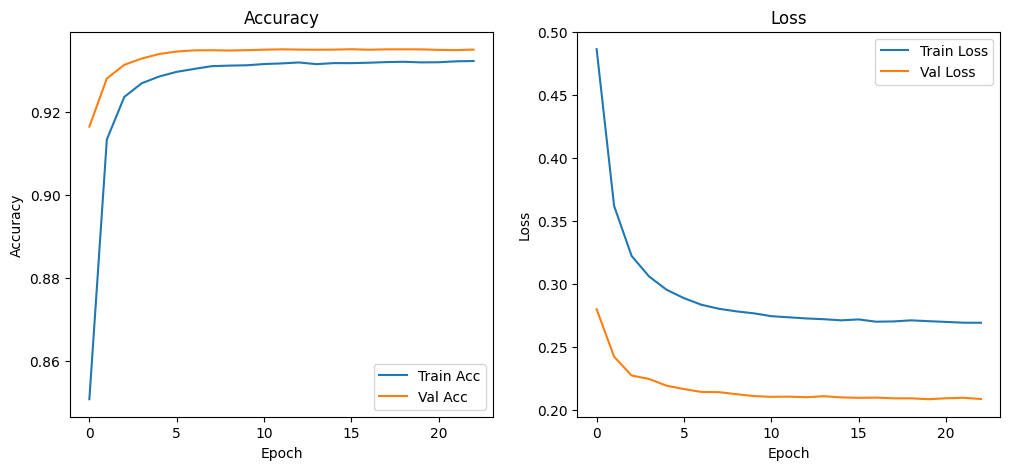

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)
